# Milestone 4 — Deep Learning ECG Classification Project

In [ ]:
# Install required libraries for Colab execution
!pip install datasets Pillow scikit-learn tensorflow joblib streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 51.9 MB/s eta 0:00:00


In [ ]:
# Import core libraries
import os
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib

print("Libraries imported successfully")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully
TensorFlow version: 2.20.0


## Data Selection

In [ ]:
# Load ECG image dataset from Hugging Face
raw_dataset = load_dataset("Amarsaish/ecg_dataset")

In [ ]:
# Convert train and test splits into pandas dataframes
df_train = pd.DataFrame(raw_dataset["train"])
df_test = pd.DataFrame(raw_dataset["test"])

In [ ]:
# Display dataset structure
print(raw_dataset)
print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)
print("Columns:", df_train.columns.tolist())

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 501
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 160
    })
})
Training data shape: (501, 2)
Test data shape: (160, 2)
Columns: ['image', 'label']


In [ ]:
# Preview Dataset
df_train.head()

,image,label
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0


In [ ]:
# Set column names used in the dataset
image_col = "image"
label_col = "label"

In [ ]:
# Display class distribution in the training data
class_counts = df_train[label_col].value_counts().sort_index()
print("Class distribution:")
print(class_counts)

Class distribution:
label
0    231
1    270
Name: count, dtype: int64


In [ ]:
# Define readable class names based on the previous milestone label mapping
class_names = ["Myocardial Infarction", "Normal ECG"]

pd.DataFrame({
    "Label": [0, 1],
    "Class Name": class_names
})

,Label,Class Name
0,0,Myocardial Infarction
1,1,Normal ECG


## Exploratory Data Analysis

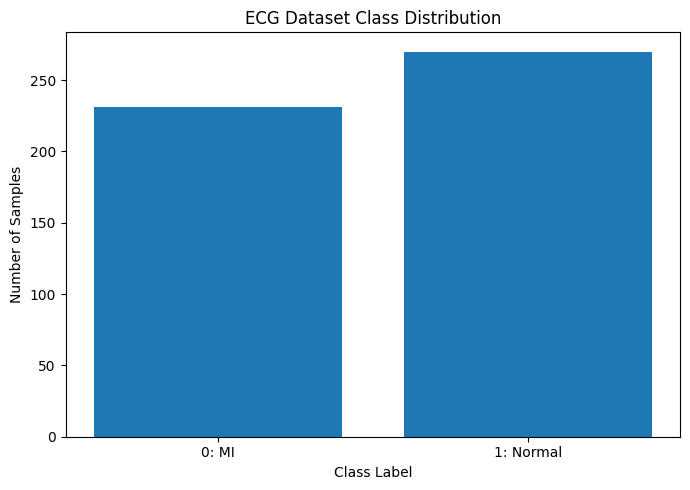

In [ ]:
# Plot class distribution
plt.figure(figsize=(7, 5))
plt.bar(["0: MI", "1: Normal"], class_counts.values)
plt.title("ECG Dataset Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

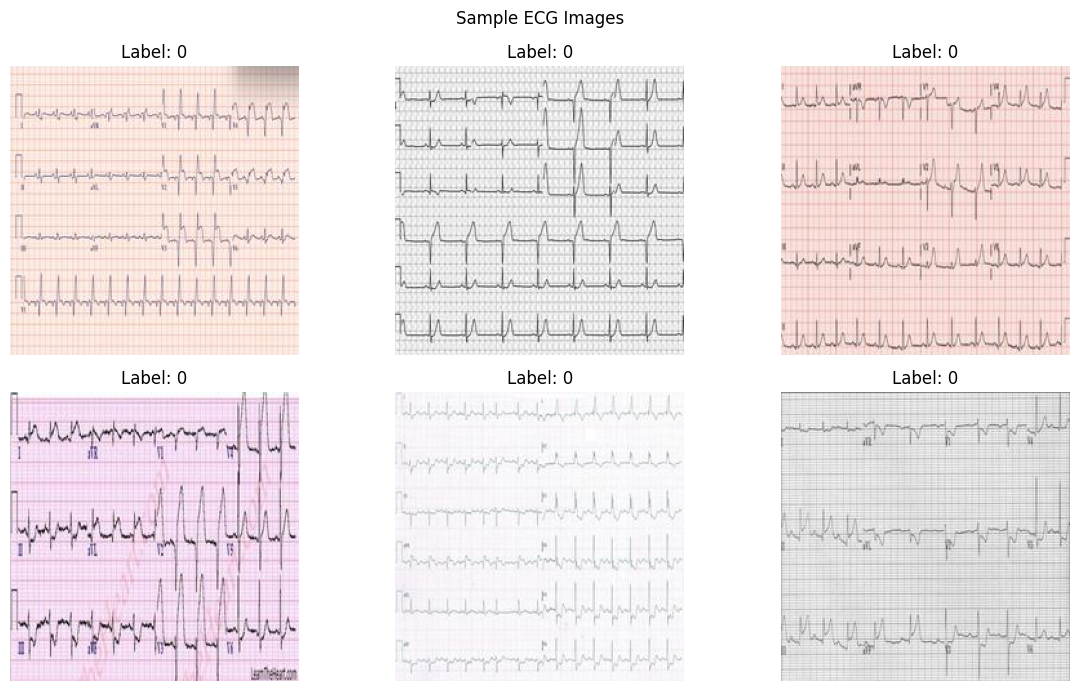

In [ ]:
# Display six sample ECG images
sample_0 = df_train[image_col].iloc[0]
sample_1 = df_train[image_col].iloc[1]
sample_2 = df_train[image_col].iloc[2]
sample_3 = df_train[image_col].iloc[3]
sample_4 = df_train[image_col].iloc[4]
sample_5 = df_train[image_col].iloc[5]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes[0, 0].imshow(sample_0, cmap="gray")
axes[0, 0].set_title("Label: " + str(df_train[label_col].iloc[0]))
axes[0, 0].axis("off")

axes[0, 1].imshow(sample_1, cmap="gray")
axes[0, 1].set_title("Label: " + str(df_train[label_col].iloc[1]))
axes[0, 1].axis("off")

axes[0, 2].imshow(sample_2, cmap="gray")
axes[0, 2].set_title("Label: " + str(df_train[label_col].iloc[2]))
axes[0, 2].axis("off")

axes[1, 0].imshow(sample_3, cmap="gray")
axes[1, 0].set_title("Label: " + str(df_train[label_col].iloc[3]))
axes[1, 0].axis("off")

axes[1, 1].imshow(sample_4, cmap="gray")
axes[1, 1].set_title("Label: " + str(df_train[label_col].iloc[4]))
axes[1, 1].axis("off")

axes[1, 2].imshow(sample_5, cmap="gray")
axes[1, 2].set_title("Label: " + str(df_train[label_col].iloc[5]))
axes[1, 2].axis("off")

plt.suptitle("Sample ECG Images")
plt.tight_layout()
plt.savefig("sample_ecg_images.png", dpi=150)
plt.show()

In [ ]:
# Check image width and height
image_sizes = df_train[image_col].map(lambda img: img.size)
image_widths = image_sizes.map(lambda size: size[0])
image_heights = image_sizes.map(lambda size: size[1])

# Create image-size summary table
image_size_summary = pd.DataFrame({
    "Statistic": ["Minimum", "Average", "Maximum"],
    "Width Pixels": [image_widths.min(), image_widths.mean(), image_widths.max()],
    "Height Pixels": [image_heights.min(), image_heights.mean(), image_heights.max()]
})

image_size_summary

,Statistic,Width Pixels,Height Pixels
0,Minimum,224.000000,224.000000
1,Average,226.173653,226.173653
2,Maximum,227.000000,227.000000


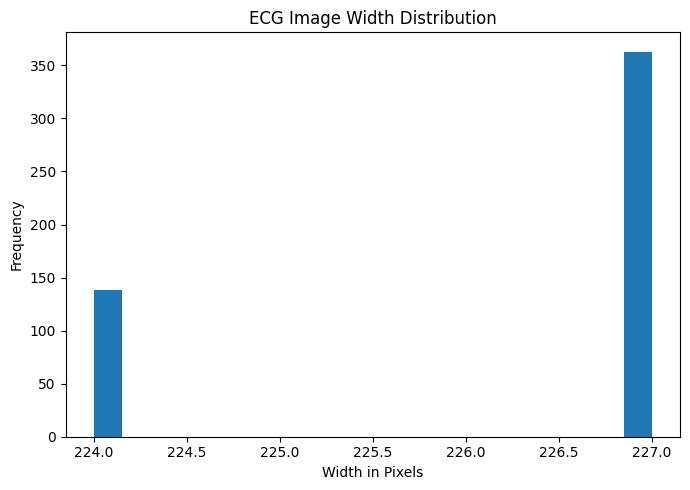

In [ ]:
# Plot width distribution
plt.figure(figsize=(7, 5))
plt.hist(image_widths, bins=20)
plt.title("ECG Image Width Distribution")
plt.xlabel("Width in Pixels")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("image_width_distribution.png", dpi=150)
plt.show()

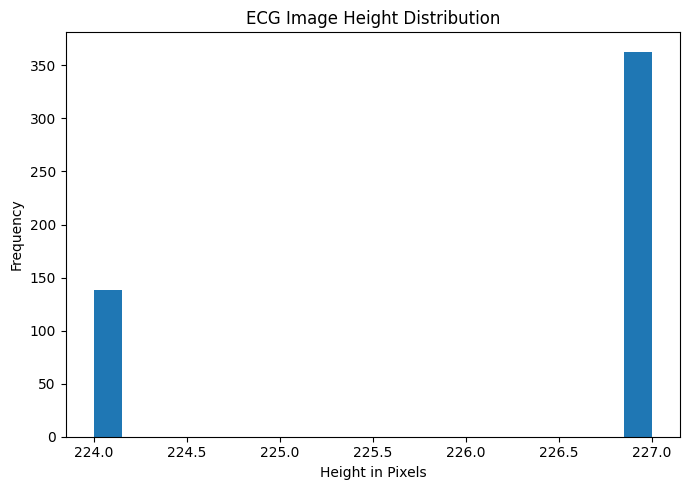

In [ ]:
# Plot height distribution
plt.figure(figsize=(7, 5))
plt.hist(image_heights, bins=20)
plt.title("ECG Image Height Distribution")
plt.xlabel("Height in Pixels")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("image_height_distribution.png", dpi=150)
plt.show()

## Data Preparation



In [ ]:
# Set reproducibility seeds
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Define image size and training parameters
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

In [ ]:
# Convert training images into resized RGB arrays
X_train_images_full = np.stack(
    df_train[image_col].map(
        lambda img: np.array(img.convert("RGB").resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32)
    ).to_numpy()
)

In [ ]:
# Convert test images into resized RGB arrays
X_test_images = np.stack(
    df_test[image_col].map(
        lambda img: np.array(img.convert("RGB").resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32)
    ).to_numpy()
)

In [ ]:
# Convert labels into integer arrays
y_train_full = df_train[label_col].astype("int32").to_numpy()
y_test = df_test[label_col].astype("int32").to_numpy()

# Display prepared array shapes
print("Full training image shape:", X_train_images_full.shape)
print("Test image shape:", X_test_images.shape)
print("Full training label shape:", y_train_full.shape)
print("Test label shape:", y_test.shape)

Full training image shape: (501, 224, 224, 3)
Test image shape: (160, 224, 224, 3)
Full training label shape: (501,)
Test label shape: (160,)


In [ ]:
# Create train-validation split from training data
X_train_images, X_val_images, y_train, y_val = train_test_split(
    X_train_images_full,
    y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

# Display final split sizes
print("Training samples:", X_train_images.shape[0])
print("Validation samples:", X_val_images.shape[0])
print("Unseen test samples:", X_test_images.shape[0])

Training samples: 425
Validation samples: 76
Unseen test samples: 160


In [ ]:
# Create light ECG-safe augmentation
augmentation_layer = tf.keras.Sequential([
    layers.RandomTranslation(height_factor=0.03, width_factor=0.03),
    layers.RandomZoom(height_factor=0.05, width_factor=0.05),
    layers.RandomContrast(factor=0.10)
], name="ecg_safe_augmentation")

## Model 1 — MobileNetV2 Transfer Learning

In [ ]:
# Build MobileNetV2 transfer learning model
mobilenet_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mobilenet_input")
mobilenet_augmented = augmentation_layer(mobilenet_input)
mobilenet_scaled = layers.Rescaling(scale=1/127.5, offset=-1, name="mobilenet_rescaling")(mobilenet_augmented)

mobilenet_base = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
mobilenet_base.trainable = False

mobilenet_features = mobilenet_base(mobilenet_scaled, training=False)
mobilenet_features = layers.GlobalAveragePooling2D(name="mobilenet_gap")(mobilenet_features)
mobilenet_features = layers.BatchNormalization(name="mobilenet_batchnorm")(mobilenet_features)
mobilenet_features = layers.Dropout(0.35, name="mobilenet_dropout")(mobilenet_features)
mobilenet_features = layers.Dense(128, activation="relu", name="mobilenet_dense")(mobilenet_features)
mobilenet_output = layers.Dense(1, activation="sigmoid", name="mobilenet_output")(mobilenet_features)

mobilenet_model = Model(mobilenet_input, mobilenet_output, name="MobileNetV2_ECG_Model")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compile Modle
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
# Model Summary
mobilenet_model.summary()

Model: "MobileNetV2_ECG_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_input (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ecg_safe_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_rescaling (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_gap                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_batchnorm             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_dropout (Dropout)     │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_dense (Dense)         │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_output (Dense)        │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# Train MobileNetV2 model
mobilenet_early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
mobilenet_reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=0.000001)

history_mobilenet = mobilenet_model.fit(
    X_train_images,
    y_train,
    validation_data=(X_val_images, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[mobilenet_early_stop, mobilenet_reduce_lr],
    verbose=1
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 978ms/step - accuracy: 0.5106 - auc: 0.4750 - loss: 0.8770 - precision: 0.5310 - recall: 0.7860 - val_accuracy: 0.4868 - val_auc: 0.6042 - val_loss: 0.6883 - val_precision: 0.5417 - val_recall: 0.3171 - learning_rate: 1.0000e-04
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 873ms/step - accuracy: 0.6447 - auc: 0.7357 - loss: 0.6432 - precision: 0.6258 - recall: 0.8472 - val_accuracy: 0.4868 - val_auc: 0.6861 - val_loss: 0.6857 - val_precision: 0.5714 - val_recall: 0.1951 - learning_rate: 1.0000e-04
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 820ms/step - accuracy: 0.7341 - auc: 0.7962 - loss: 0.5545 - precision: 0.7117 - recall: 0.8515 - val_accuracy: 0.5263 - val_auc: 0.7432 - val_loss: 0.6862 - val_precision: 0.7778 - val_recall: 0.1707 - learning_rate: 1.0000e-04
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 796ms/step - accuracy: 0.7976 - auc: 0.8778 - loss: 0.4497 - precision: 0.7804 - recall: 0.8690 - val_accuracy: 0.5132 - val_auc: 0.7819 - val_lo

In [ ]:
# Evaluate MobileNetV2 on unseen test data
mobilenet_eval = mobilenet_model.evaluate(X_test_images, y_test, verbose=0, return_dict=True)
mobilenet_prob = np.ravel(mobilenet_model.predict(X_test_images, verbose=0))
mobilenet_pred = (mobilenet_prob >= 0.5).astype("int32")

mobilenet_accuracy = accuracy_score(y_test, mobilenet_pred)
mobilenet_precision = precision_score(y_test, mobilenet_pred, average="weighted", zero_division=0)
mobilenet_recall = recall_score(y_test, mobilenet_pred, average="weighted", zero_division=0)
mobilenet_f1 = f1_score(y_test, mobilenet_pred, average="weighted", zero_division=0)

print("MobileNetV2 Test Results")
print("Accuracy :", round(mobilenet_accuracy, 4))
print("Precision:", round(mobilenet_precision, 4))
print("Recall   :", round(mobilenet_recall, 4))
print("F1 Score :", round(mobilenet_f1, 4))
print("AUC      :", round(mobilenet_eval["auc"], 4))

print("\nClassification Report")
print(classification_report(y_test, mobilenet_pred, target_names=class_names, zero_division=0))

MobileNetV2 Test Results
Accuracy : 0.6062
Precision: 0.6387
Recall   : 0.6062
F1 Score : 0.5631
AUC      : 0.6767

Classification Report
                       precision    recall  f1-score   support

Myocardial Infarction       0.58      0.89      0.71        85
           Normal ECG       0.70      0.28      0.40        75

             accuracy                           0.61       160
            macro avg       0.64      0.59      0.55       160
         weighted avg       0.64      0.61      0.56       160



## Model 2 — ResNet50V2 Transfer Learning


In [ ]:
# Build ResNet50V2 transfer learning model
resnet_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="resnet_input")
resnet_augmented = augmentation_layer(resnet_input)
resnet_scaled = layers.Rescaling(scale=1/127.5, offset=-1, name="resnet_rescaling")(resnet_augmented)

resnet_base = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
resnet_base.trainable = False

resnet_features = resnet_base(resnet_scaled, training=False)
resnet_features = layers.GlobalAveragePooling2D(name="resnet_gap")(resnet_features)
resnet_features = layers.BatchNormalization(name="resnet_batchnorm")(resnet_features)
resnet_features = layers.Dropout(0.40, name="resnet_dropout")(resnet_features)
resnet_features = layers.Dense(128, activation="relu", name="resnet_dense")(resnet_features)
resnet_output = layers.Dense(1, activation="sigmoid", name="resnet_output")(resnet_features)

resnet_model = Model(resnet_input, resnet_output, name="ResNet50V2_ECG_Model")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compile Model
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
# Model Summary
resnet_model.summary()

Model: "ResNet50V2_ECG_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet_input (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ecg_safe_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_rescaling (Rescaling)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_gap                      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_batchnorm                │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_dropout (Dropout)        │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_dense (Dense)            │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_output (Dense)           │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,835,393 (90.92 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [ ]:
# Train ResNet50V2 model
resnet_early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
resnet_reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=0.000001)

history_resnet = resnet_model.fit(
    X_train_images,
    y_train,
    validation_data=(X_val_images, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[resnet_early_stop, resnet_reduce_lr],
    verbose=1
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.5506 - auc: 0.5777 - loss: 0.7346 - precision: 0.5913 - recall: 0.5371 - val_accuracy: 0.6316 - val_auc: 0.6634 - val_loss: 0.6635 - val_precision: 0.6000 - val_recall: 0.9512 - learning_rate: 1.0000e-04
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.7153 - auc: 0.7744 - loss: 0.5760 - precision: 0.7288 - recall: 0.7511 - val_accuracy: 0.6711 - val_auc: 0.8101 - val_loss: 0.6177 - val_precision: 0.6379 - val_recall: 0.9024 - learning_rate: 1.0000e-04
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.7882 - auc: 0.8403 - loss: 0.5101 - precision: 0.7957 - recall: 0.8166 - val_accuracy: 0.7500 - val_auc: 0.8770 - val_loss: 0.5820 - val_precision: 0.7292 - val_recall: 0.8537 - learning_rate: 1.0000e-04
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.8235 - auc: 0.8806 - loss: 0.4523 - precision: 0.8319 - recall: 0.8428 - val_accuracy: 0.7763 - val_auc: 0.9125 - val_loss: 0.5536 

In [ ]:
# Evaluate ResNet50V2 on unseen test data
resnet_eval = resnet_model.evaluate(X_test_images, y_test, verbose=0, return_dict=True)
resnet_prob = np.ravel(resnet_model.predict(X_test_images, verbose=0))
resnet_pred = (resnet_prob >= 0.5).astype("int32")

resnet_accuracy = accuracy_score(y_test, resnet_pred)
resnet_precision = precision_score(y_test, resnet_pred, average="weighted", zero_division=0)
resnet_recall = recall_score(y_test, resnet_pred, average="weighted", zero_division=0)
resnet_f1 = f1_score(y_test, resnet_pred, average="weighted", zero_division=0)

print("ResNet50V2 Test Results")
print("Accuracy :", round(resnet_accuracy, 4))
print("Precision:", round(resnet_precision, 4))
print("Recall   :", round(resnet_recall, 4))
print("F1 Score :", round(resnet_f1, 4))
print("AUC      :", round(resnet_eval["auc"], 4))

print("\nClassification Report")
print(classification_report(y_test, resnet_pred, target_names=class_names, zero_division=0))

ResNet50V2 Test Results
Accuracy : 0.9187
Precision: 0.9188
Recall   : 0.9187
F1 Score : 0.9187
AUC      : 0.9769

Classification Report
                       precision    recall  f1-score   support

Myocardial Infarction       0.92      0.93      0.92        85
           Normal ECG       0.92      0.91      0.91        75

             accuracy                           0.92       160
            macro avg       0.92      0.92      0.92       160
         weighted avg       0.92      0.92      0.92       160



## Model 3 — EfficientNetB0 Transfer Learning


In [ ]:
# Build EfficientNetB0 transfer learning model
efficientnet_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="efficientnet_input")
efficientnet_augmented = augmentation_layer(efficientnet_input)

efficientnet_base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
efficientnet_base.trainable = False

efficientnet_features = efficientnet_base(efficientnet_augmented, training=False)
efficientnet_features = layers.GlobalAveragePooling2D(name="efficientnet_gap")(efficientnet_features)
efficientnet_features = layers.BatchNormalization(name="efficientnet_batchnorm")(efficientnet_features)
efficientnet_features = layers.Dropout(0.35, name="efficientnet_dropout")(efficientnet_features)
efficientnet_features = layers.Dense(128, activation="relu", name="efficientnet_dense")(efficientnet_features)
efficientnet_output = layers.Dense(1, activation="sigmoid", name="efficientnet_output")(efficientnet_features)

efficientnet_model = Model(efficientnet_input, efficientnet_output, name="EfficientNetB0_ECG_Model")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
efficientnet_model.summary()

Model: "EfficientNetB0_ECG_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnet_input (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ecg_safe_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_gap                │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_batchnorm          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_dropout (Dropout)  │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_dense (Dense)      │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_output (Dense)     │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# Train EfficientNetB0 model
efficientnet_early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
efficientnet_reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=0.000001)

history_efficientnet = efficientnet_model.fit(
    X_train_images,
    y_train,
    validation_data=(X_val_images, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[efficientnet_early_stop, efficientnet_reduce_lr],
    verbose=1
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5835 - auc: 0.6404 - loss: 0.7241 - precision: 0.6477 - recall: 0.4978 - val_accuracy: 0.4605 - val_auc: 0.4875 - val_loss: 0.7189 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6494 - auc: 0.7053 - loss: 0.6428 - precision: 0.6887 - recall: 0.6376 - val_accuracy: 0.5526 - val_auc: 0.6098 - val_loss: 0.6842 - val_precision: 0.6207 - val_recall: 0.4390 - learning_rate: 1.0000e-04
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7341 - auc: 0.8092 - loss: 0.5294 - precision: 0.7500 - recall: 0.7598 - val_accuracy: 0.6316 - val_auc: 0.6798 - val_loss: 0.6648 - val_precision: 0.6512 - val_recall: 0.6829 - learning_rate: 1.0000e-04
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7553 - auc: 0.8283 - loss: 0.5113 - precision: 0.7753 - recall: 0.7686 - val_accuracy: 0.6974 - val_auc: 0.7373 - val_loss: 

In [ ]:
# Evaluate EfficientNetB0 on unseen test data
efficientnet_eval = efficientnet_model.evaluate(X_test_images, y_test, verbose=0, return_dict=True)
efficientnet_prob = np.ravel(efficientnet_model.predict(X_test_images, verbose=0))
efficientnet_pred = (efficientnet_prob >= 0.5).astype("int32")

efficientnet_accuracy = accuracy_score(y_test, efficientnet_pred)
efficientnet_precision = precision_score(y_test, efficientnet_pred, average="weighted", zero_division=0)
efficientnet_recall = recall_score(y_test, efficientnet_pred, average="weighted", zero_division=0)
efficientnet_f1 = f1_score(y_test, efficientnet_pred, average="weighted", zero_division=0)

print("EfficientNetB0 Test Results")
print("Accuracy :", round(efficientnet_accuracy, 4))
print("Precision:", round(efficientnet_precision, 4))
print("Recall   :", round(efficientnet_recall, 4))
print("F1 Score :", round(efficientnet_f1, 4))
print("AUC      :", round(efficientnet_eval["auc"], 4))

print("\nClassification Report")
print(classification_report(y_test, efficientnet_pred, target_names=class_names, zero_division=0))

EfficientNetB0 Test Results
Accuracy : 0.8438
Precision: 0.8625
Recall   : 0.8438
F1 Score : 0.8403
AUC      : 0.9598

Classification Report
                       precision    recall  f1-score   support

Myocardial Infarction       0.79      0.96      0.87        85
           Normal ECG       0.95      0.71      0.81        75

             accuracy                           0.84       160
            macro avg       0.87      0.84      0.84       160
         weighted avg       0.86      0.84      0.84       160



## Results and Analysis


In [ ]:
# Create final model comparison table
comparison_df = pd.DataFrame({
    "Model": ["MobileNetV2", "ResNet50V2", "EfficientNetB0"],
    "Accuracy": [mobilenet_accuracy, resnet_accuracy, efficientnet_accuracy],
    "Precision": [mobilenet_precision, resnet_precision, efficientnet_precision],
    "Recall": [mobilenet_recall, resnet_recall, efficientnet_recall],
    "F1 Score": [mobilenet_f1, resnet_f1, efficientnet_f1],
    "AUC": [mobilenet_eval["auc"], resnet_eval["auc"], efficientnet_eval["auc"]]
})

# Sort models by F1-score
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,ResNet50V2,0.91875,0.918752,0.91875,0.918715,0.976863
1,EfficientNetB0,0.84375,0.862509,0.84375,0.840273,0.959765
2,MobileNetV2,0.60625,0.638702,0.60625,0.563081,0.676706


In [ ]:
# Save comparison results
os.makedirs("milestone4_outputs", exist_ok=True)
comparison_df.to_csv("milestone4_outputs/model_comparison_results.csv", index=False)

print("Model comparison saved to milestone4_outputs/model_comparison_results.csv")

Model comparison saved to milestone4_outputs/model_comparison_results.csv


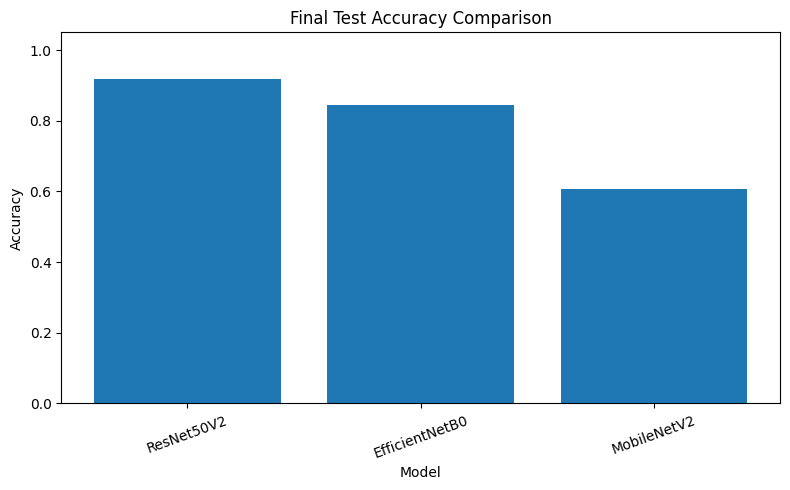

In [ ]:
# Plot final accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Final Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("milestone4_outputs/final_accuracy_comparison.png", dpi=150)
plt.show()

<Figure size 600x500 with 0 Axes>

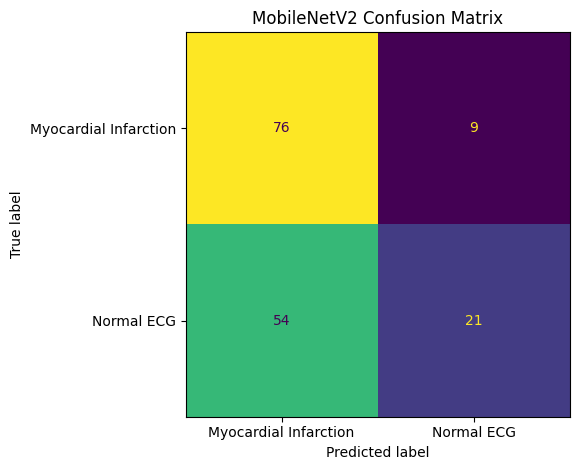

In [ ]:
# MobileNetV2 confusion matrix
cm_mobilenet = confusion_matrix(y_test, mobilenet_pred)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm_mobilenet, display_labels=class_names).plot(colorbar=False)
plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.savefig("milestone4_outputs/mobilenet_confusion_matrix.png", dpi=150)
plt.show()

<Figure size 600x500 with 0 Axes>

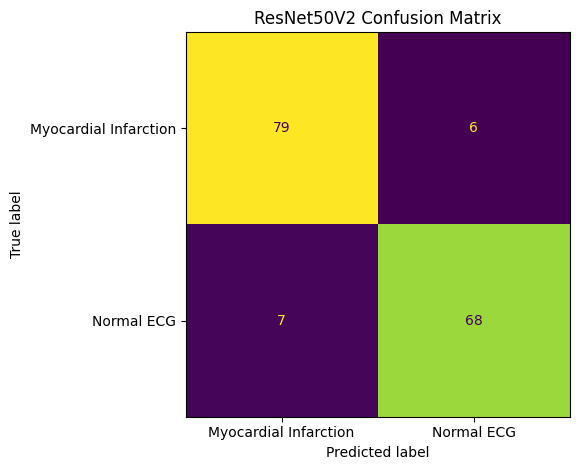

In [ ]:
# ResNet50V2 confusion matrix
cm_resnet = confusion_matrix(y_test, resnet_pred)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm_resnet, display_labels=class_names).plot(colorbar=False)
plt.title("ResNet50V2 Confusion Matrix")
plt.tight_layout()
plt.savefig("milestone4_outputs/resnet_confusion_matrix.png", dpi=150)
plt.show()

<Figure size 600x500 with 0 Axes>

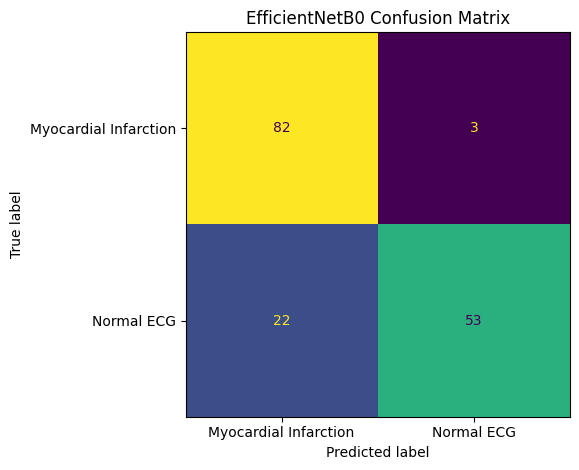

In [ ]:
# EfficientNetB0 confusion matrix
cm_efficientnet = confusion_matrix(y_test, efficientnet_pred)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm_efficientnet, display_labels=class_names).plot(colorbar=False)
plt.title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.savefig("milestone4_outputs/efficientnet_confusion_matrix.png", dpi=150)
plt.show()

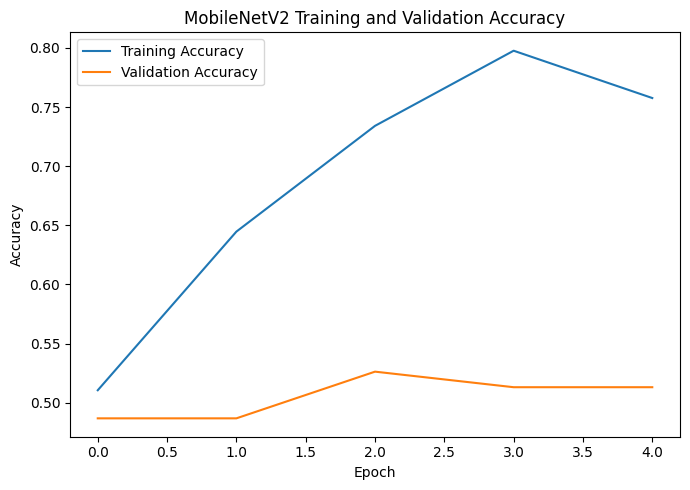

In [ ]:
# Plot MobileNetV2 training curves
plt.figure(figsize=(7, 5))
plt.plot(history_mobilenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("milestone4_outputs/mobilenet_accuracy_curve.png", dpi=150)
plt.show()

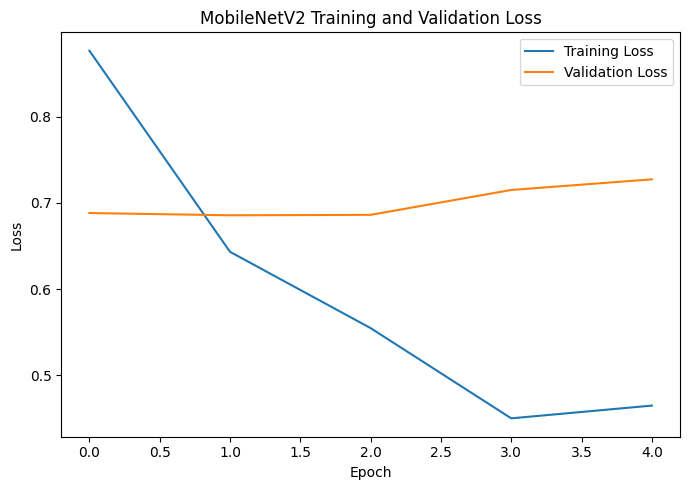

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history_mobilenet.history["loss"], label="Training Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("milestone4_outputs/mobilenet_loss_curve.png", dpi=150)
plt.show()

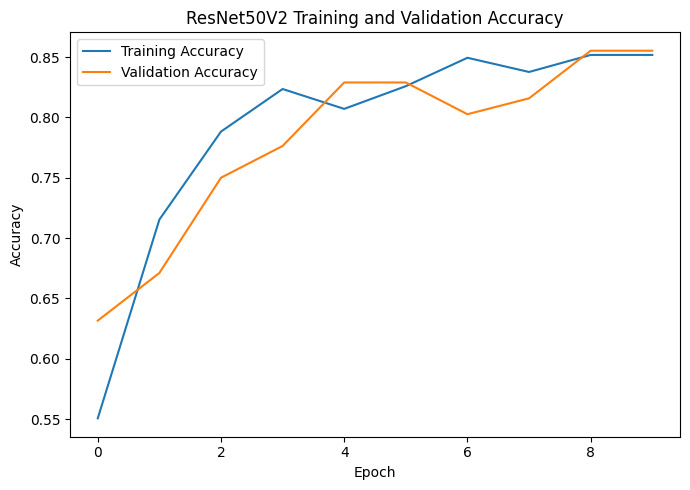

In [ ]:
# Plot ResNet50V2 training curves
plt.figure(figsize=(7, 5))
plt.plot(history_resnet.history["accuracy"], label="Training Accuracy")
plt.plot(history_resnet.history["val_accuracy"], label="Validation Accuracy")
plt.title("ResNet50V2 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("milestone4_outputs/resnet_accuracy_curve.png", dpi=150)
plt.show()

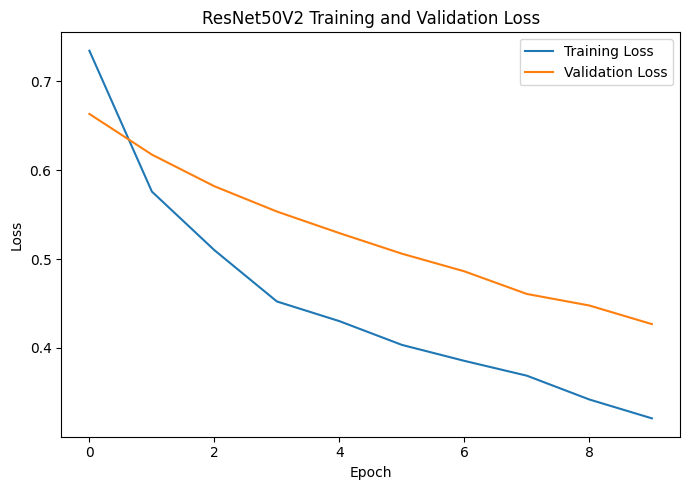

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history_resnet.history["loss"], label="Training Loss")
plt.plot(history_resnet.history["val_loss"], label="Validation Loss")
plt.title("ResNet50V2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("milestone4_outputs/resnet_loss_curve.png", dpi=150)
plt.show()

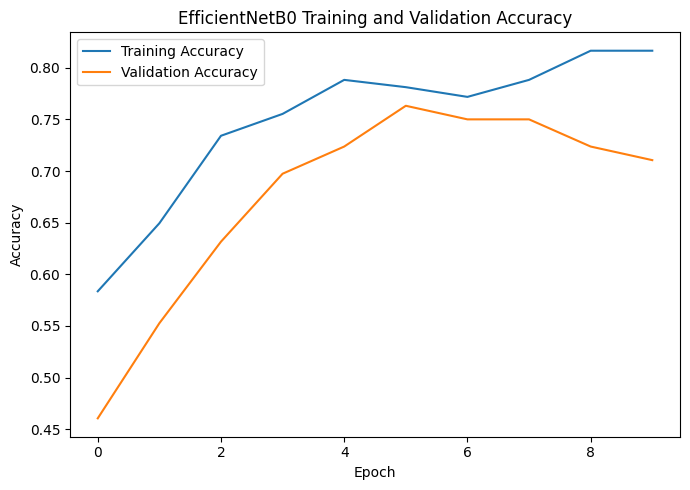

In [ ]:
# Plot EfficientNetB0 training curves
plt.figure(figsize=(7, 5))
plt.plot(history_efficientnet.history["accuracy"], label="Training Accuracy")
plt.plot(history_efficientnet.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("milestone4_outputs/efficientnet_accuracy_curve.png", dpi=150)
plt.show()

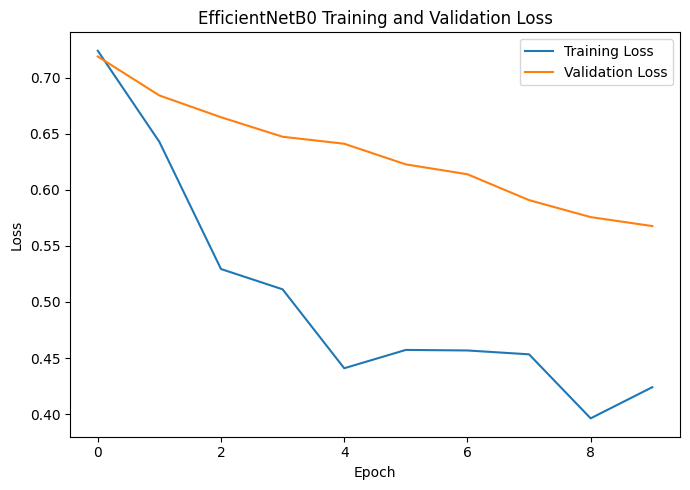

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history_efficientnet.history["loss"], label="Training Loss")
plt.plot(history_efficientnet.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("milestone4_outputs/efficientnet_loss_curve.png", dpi=150)
plt.show()

## Testing With New / Unseen Data

Best model based on F1 Score: ResNet50V2


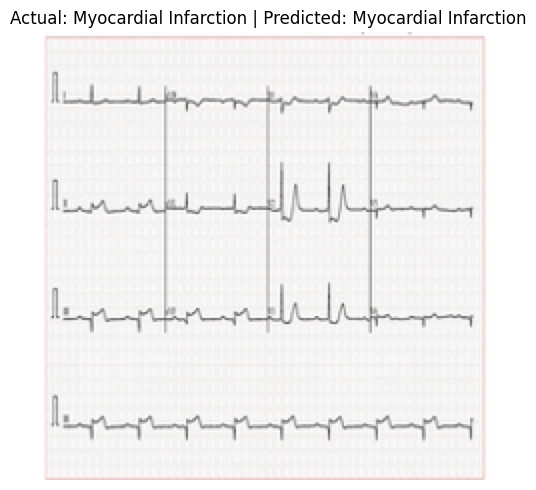

Actual class: Myocardial Infarction
Predicted class: Myocardial Infarction
Prediction probability for class 1: 0.3173


In [ ]:
# Select best model name from comparison table
best_model_name = comparison_df.loc[0, "Model"]
print("Best model based on F1 Score:", best_model_name)

# Select the corresponding trained model
selected_model = mobilenet_model
selected_prediction = mobilenet_pred
selected_probability = mobilenet_prob

selected_model = resnet_model if best_model_name == "ResNet50V2" else selected_model
selected_prediction = resnet_pred if best_model_name == "ResNet50V2" else selected_prediction
selected_probability = resnet_prob if best_model_name == "ResNet50V2" else selected_probability

selected_model = efficientnet_model if best_model_name == "EfficientNetB0" else selected_model
selected_prediction = efficientnet_pred if best_model_name == "EfficientNetB0" else selected_prediction
selected_probability = efficientnet_prob if best_model_name == "EfficientNetB0" else selected_probability

# Test one unseen ECG image
sample_index = 0
sample_image = X_test_images[sample_index].astype("uint8")
sample_actual = y_test[sample_index]
sample_predicted = selected_prediction[sample_index]
sample_confidence = selected_probability[sample_index]

plt.figure(figsize=(7, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title("Actual: " + class_names[sample_actual] + " | Predicted: " + class_names[sample_predicted])
plt.tight_layout()
plt.savefig("milestone4_outputs/unseen_sample_prediction.png", dpi=150)
plt.show()

print("Actual class:", class_names[sample_actual])
print("Predicted class:", class_names[sample_predicted])
print("Prediction probability for class 1:", round(float(sample_confidence), 4))